# Satellite Image Semantic Segmentation Based on Fully Convolutional Network (FCN) using Tensorflow
- This notebook is designed to introduce satellite image semantic segmentation using a Fully Convolutional Network (FCN) with the TensorFlow library.
- The dataset used in this example consists of Sentinel-2 imagery with its corresponidng label for binary mangrove cassification. (Originally from: https://www.researchgate.net/publication/376173191_Modified_U-Net_by_Adding_Twin_Extractors_for_Multi-Sensor_Satellite_Images_Fusion_to_Map_Mangrove_Forest)

- In this notebook, we will learn how to load and prepare the dataset, construct simple FCN architecture, training model, and evaluation assessment.


**Ying-Nong Chen's Lab: https://sites.google.com/view/yingnongchen**

## Dataset Preparation
- This notebook will use GPU (so make sure to turn on GPU in the Colab: --> Runtime --> Change runtime type --> Select T4 GPU)
- This notebook will use the image dataset saved in our Google Drive (Please download the example of dataset used from this following link:
https://drive.google.com/drive/folders/11jWqNUtI9Jyiv76KnWaOp3ipOGwnC-jy?usp=sharing)

In [1]:
## Import used libraries
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# Tensorflow library
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

In [2]:
# Set random seed for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [3]:
# check whether used GPU or CPU and set to device
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Using GPU: {gpus[0].name}")
    tf.config.experimental.set_memory_growth(gpus[0], True)
else:
    print("GPU not found, using CPU")


Using GPU: /physical_device:GPU:0


### Load Image Dataset from Google Drive
- Please firstly download the example of Face Dataset and placed into your Google Drive
- Connect your Google Drive for this notebook

In [ ]:
## Mounting to Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

#### Load image dataset

* We have two sub-folders, namely Images and Masks.
* Images sub-folder is consists of RGB or true color Sentinel-2 imageyr
* Masks sub-folder is consist of label masks or target data



In [4]:
# Define path for our Face folder
data_dir = "/content/drive/MyDrive/Invited Fo Guang Univ/Satellite_Datasets" # change it according with Face folder path

image_dir = os.path.join(data_dir, "Images")  # RGB Sentinel-2 images
mask_dir  = os.path.join(data_dir, "Masks")   # label masks (0: non-mangrove, 1: mangrove)

print("Image directory:", image_dir)
print("Mask directory:", mask_dir)

Image directory: /content/drive/MyDrive/Invited Fo Guang Univ/Satellite_Datasets/Images
Mask directory: /content/drive/MyDrive/Invited Fo Guang Univ/Satellite_Datasets/Masks


#### Load Data

In [5]:
IMG_SIZE = 128 # Define the image shape (HxW)
NUM_CLASSES = 2 # (0: non-mangrove, 1: mangrove)

# create function to load RGB image and label mask image
def load_image_mask(img_path, mask_path):
    # Load RGB image
    img = tf.keras.preprocessing.image.load_img(
        img_path, target_size=(IMG_SIZE, IMG_SIZE)
    )
    img = tf.keras.preprocessing.image.img_to_array(img)
    img = img / 255.0  # normalize to [0,1]

    # Load mask (single-channel)
    mask = tf.keras.preprocessing.image.load_img(
        mask_path, target_size=(IMG_SIZE, IMG_SIZE), color_mode="grayscale"
    )
    mask = tf.keras.preprocessing.image.img_to_array(mask)
    mask = mask.squeeze().astype(np.int32)

    # Convert 0/255 masks to 0 or 1
    mask = (mask > 127).astype(np.int32)

    return img, mask

In [6]:
# Sort the list directory of images and labels
image_files = sorted(os.listdir(image_dir))
mask_files  = sorted(os.listdir(mask_dir))

print("Number of images:", len(image_files))
print("Number of masks:", len(mask_files))
print("Image files:", image_files[:5])
print("Mask files:", mask_files[:5])

Number of images: 361
Number of masks: 361
Image files: ['img_patch_0000.png', 'img_patch_0001.png', 'img_patch_0002.png', 'img_patch_0003.png', 'img_patch_0004.png']
Mask files: ['mask_patch_0000.png', 'mask_patch_0001.png', 'mask_patch_0002.png', 'mask_patch_0003.png', 'mask_patch_0004.png']


In [7]:
# Initialize empty lists to store image and label data
images, masks = [], []

# Loop through image and mask filenames together
for img_f, mask_f in zip(image_files, mask_files):
    # use load_image_mask function to load an image and its corresponding mask
    img, mask = load_image_mask(
        os.path.join(image_dir, img_f),
        os.path.join(mask_dir, mask_f)
    )
    images.append(img) # Add the loaded image to the images list
    masks.append(mask) # Add the loaded mask to the masks list

# Convert list of images into a NumPy array
images = np.array(images)
masks  = np.array(masks)

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)

Images shape: (361, 128, 128, 3)
Masks shape: (361, 128, 128)


In [8]:
# Check the class of the label mask
np.unique(masks)

array([0, 1], dtype=int32)

### Visualize image example

In [9]:
# Create function to define the class color for each class
def colorize_mask(mask):
    # Define class colors: 0 = Water (Blue), 1 = Mangrove (Dark Green)
    class_colors = np.array([
        [0, 0, 255],   # Water
        [0, 128, 0],   # Mangrove
    ])

    return class_colors[mask]


# Create function to normalize RGB image for plotting
def normalize_rgb(img):
    img = np.clip(img, 0, None)  # Remove negative values if any
    img_min = img.min()
    img_max = img.max()
    if img_max > img_min:
        img = (img - img_min) / (img_max - img_min)
    return img

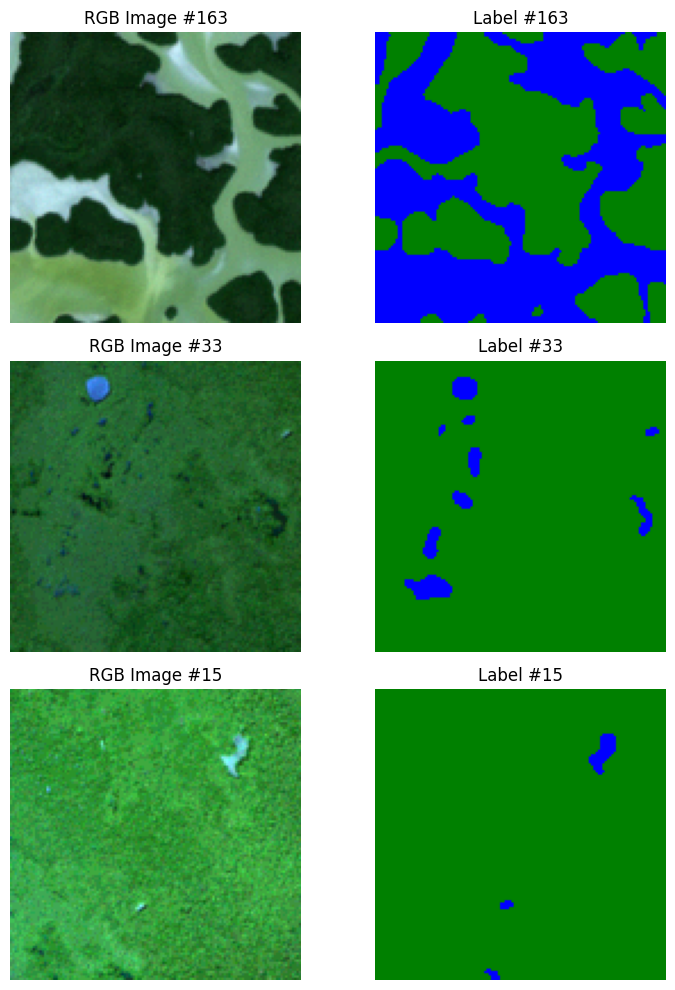

In [10]:
# Randomly select 3 indices
num_samples = 3
random_indices = np.random.choice(len(images), num_samples, replace=False)

# Plot Images and corresponding labels
plt.figure(figsize=(8, 10))
for i, idx in enumerate(random_indices):
    # Plot normalized RGB image
    plt.subplot(num_samples, 2, i*2 + 1)
    plt.imshow(normalize_rgb(images[idx]))
    plt.title(f"RGB Image #{idx}")
    plt.axis("off")

    # Plot mask
    plt.subplot(num_samples, 2, i*2 + 2)
    plt.imshow(colorize_mask(masks[idx]))
    plt.title(f"Label #{idx}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Split data (Training and Testing)
* We will use 70% of our dataset as the training data and remaining 30% as the testing

In [12]:
from sklearn.model_selection import train_test_split

## Split Training and Testing Datasets
X_train, X_test, y_train, y_test = train_test_split(
    images, masks, test_size=0.3, random_state=seed
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 252
Testing samples: 109


### FCN Model building
* We will perform a simple FCN model that consists of Encoder and Decoder
* The **encoder** has three Conv2D layers with ReLU activation, each followed by MaxPooling for downsampling.
* A single convolutional layer is placed between the encoder and decoder as the bottleneck.
* The **decoder** uses three UpSampling2D layers, each followed by a Conv2D layer
* The **final output** is produced using a point-wise (1×1) Conv2D layer with sigmoid activation.

In [14]:
def build_fcn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape) # Input: (128, 128, 3)

    # Encoder (Downsampling)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(inputs) # (128, 128, 64)
    x = layers.MaxPooling2D()(x) # using maxpooling to downsampling the image size become: (64, 64, 64)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x) # (64, 64, 128)
    x = layers.MaxPooling2D()(x) # using maxpooling to downsampling the image size become: (32, 32, 128)

    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x) # (32, 32, 256)
    x = layers.MaxPooling2D()(x) # using maxpooling to downsampling the image size become: (16, 16, 256)

    # Fully convolutional layers (Bottleneck)
    x = layers.Conv2D(512, 3, padding="same", activation="relu")(x) # (16, 16, 512)

    # Decoder (Upsampling)
    x = layers.UpSampling2D()(x) # using upsampling to upsampling the image size become: (32, 32, 512)
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x) # (32, 32, 256)

    x = layers.UpSampling2D()(x) # using upsampling to upsampling the image size become: (64, 64, 256)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x) # (64, 64, 128)

    x = layers.UpSampling2D()(x) # using upsampling to upsampling the image size become: (128, 128, 128)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x) # (128, 128, 64)

    # Output layer
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(x) # use sigmoid because we perform binary calssification, use softmaxk if more than 2 classes

    return models.Model(inputs, outputs)

In [15]:
model = build_fcn() # Build model
model.summary() # print summary of the model

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 32, 32, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 256)    │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 128, 128, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 128, 128, 1)    │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,099,777 (11.82 MB)

 Trainable params: 3,099,777 (11.82 MB)

 Non-trainable params: 0 (0.00 B)

#### Set the training details

In [16]:
# Compile model
model.compile(
    optimizer=Adam(learning_rate=1e-4),  # Use Adam optimizer
    loss="binary_crossentropy",           # Binary cross-entropy loss for 2-class segmentation
    metrics=["accuracy"]                  # Track accuracy during training
)

In [17]:
# set the training details
BATCH_SIZE = 16  # Number of samples per gradient update
EPOCHS = 75     # Number of times the model will see the entire dataset during training

# Save model during training
checkpoint = ModelCheckpoint(
    "fcn_best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

#### Start the training process

In [18]:
# In the tensorflow model, we can directly used the .fit function to train the model with the specific training details that we have defined
history = model.fit(
    X_train, y_train,          # Training data and corresponding masks
    validation_split=0.2,      # Use 20% of training data for validation
    epochs=EPOCHS,             # Number of epochs
    batch_size=BATCH_SIZE,     # Number of batch_size
    callbacks=[checkpoint]     # Save the best model during training
)


Epoch 1/75
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6287 - loss: 0.6750  
Epoch 1: val_loss improved from inf to 0.53029, saving model to fcn_best_model.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.6329 - loss: 0.6729 - val_accuracy: 0.6963 - val_loss: 0.5303
Epoch 2/75
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.6913 - loss: 0.5261
Epoch 2: val_loss improved from 0.53029 to 0.51385, saving model to fcn_best_model.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.6937 - loss: 0.5240 - val_accuracy: 0.6963 - val_loss: 0.5139
Epoch 3/75
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.6913 - loss: 0.5010
Epoch 3: val_loss improved from 0.51385 to 0.47203, saving model to fcn_best_model.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.6937 - loss: 0.4990 - val_accuracy: 0.6963 - val_loss: 0.4720
Epoch 4/75
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.6913 - loss: 0.4524
Epoch 4: val_loss improved from 0.47203 to 0.403

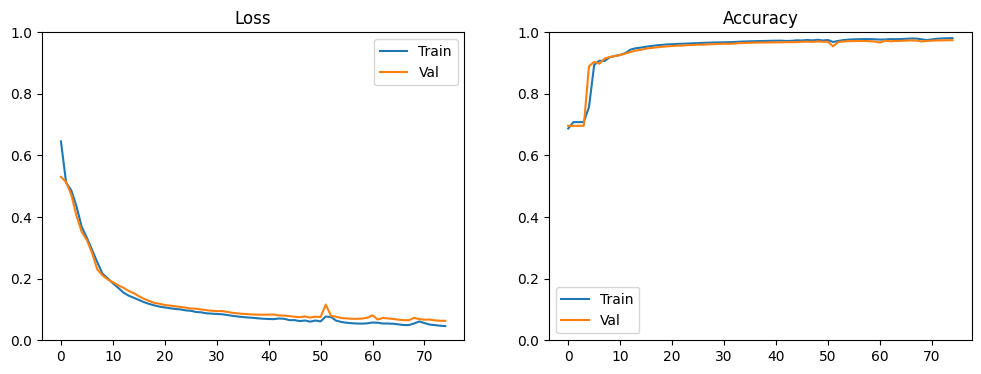

In [19]:
# Plot the Loss and Accuracy Curves
plt.figure(figsize=(12, 4))

# sub-plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss")
plt.ylim(0, 1)
plt.legend()

# sub-plot acc
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.title("Accuracy")
plt.ylim(0, 1)
plt.legend()

plt.show()

#### Inference Process (Predict the testing dataset)

In [20]:
# Load the best model weights
model.load_weights("fcn_best_model.keras")

In [21]:
# Inference process to predict the testing dataset
y_pred = model.predict(X_test)
print("Prediction shape:", y_pred.shape)

4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step
Prediction shape: (109, 128, 128, 1)


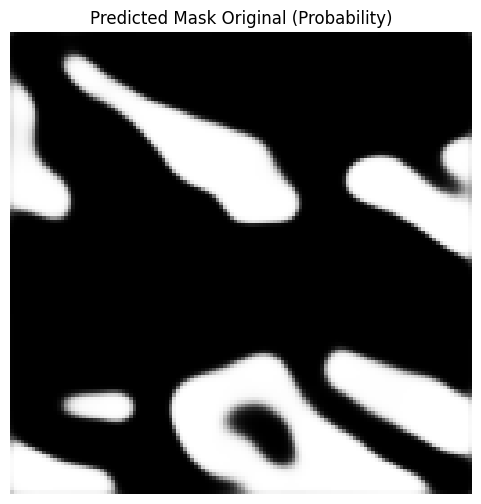

In [25]:
# Show a single prediction example
plt.figure(figsize=(6, 6))
plt.imshow(y_pred[25, :, :, 0] , cmap='gray')  # Display predicted mask in grayscale
plt.title("Predicted Mask Original (Probability)")
plt.axis('off')
plt.show()

In [23]:
# Convert probabilities → binary labels
y_pred_labels = (y_pred >= 0.5).astype(np.uint8)
print("Prediction labels shape original:", y_pred_labels.shape)

# Remove channel dimension
y_pred_labels = y_pred_labels.squeeze(axis=-1)
print("Prediction labels shape final:", y_pred_labels.shape)

Prediction labels shape original: (109, 128, 128, 1)
Prediction labels shape final: (109, 128, 128)


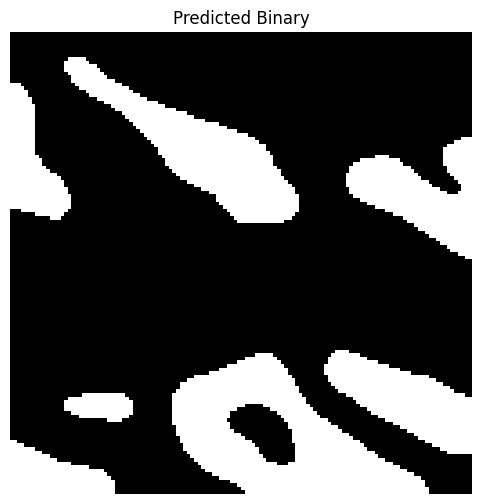

In [24]:
# Shows example of the binary predicted image
plt.figure(figsize=(6, 6))
plt.imshow(y_pred_labels[25, :, :], cmap='gray')  # Display predicted mask in grayscale
plt.title("Predicted Binary")
plt.axis('off')
plt.show()

#### Accruacy assessments

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Flatten arrays to 1D for accuracy calculation
y_pred_flat = y_pred_labels.flatten()
y_test_flat = y_test.flatten()

# Compute Overall Accuracy (OA)
oa = accuracy_score(y_test_flat, y_pred_flat)
print("Overall Accuracy (OA):", oa)

Overall Accuracy (OA): 0.9780687804615825


In [27]:
# Compute classification report
report = classification_report(y_test_flat, y_pred_flat, target_names=["Water", "Mangrove"])
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

       Water       0.99      0.98      0.98   1282156
    Mangrove       0.95      0.97      0.96    503700

    accuracy                           0.98   1785856
   macro avg       0.97      0.98      0.97   1785856
weighted avg       0.98      0.98      0.98   1785856



In [28]:
# Compute confusion matrix
cm = confusion_matrix(y_test_flat, y_pred_flat)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[1258942   23214]
 [  15952  487748]]


### Shows example of predicted results on testing dataset

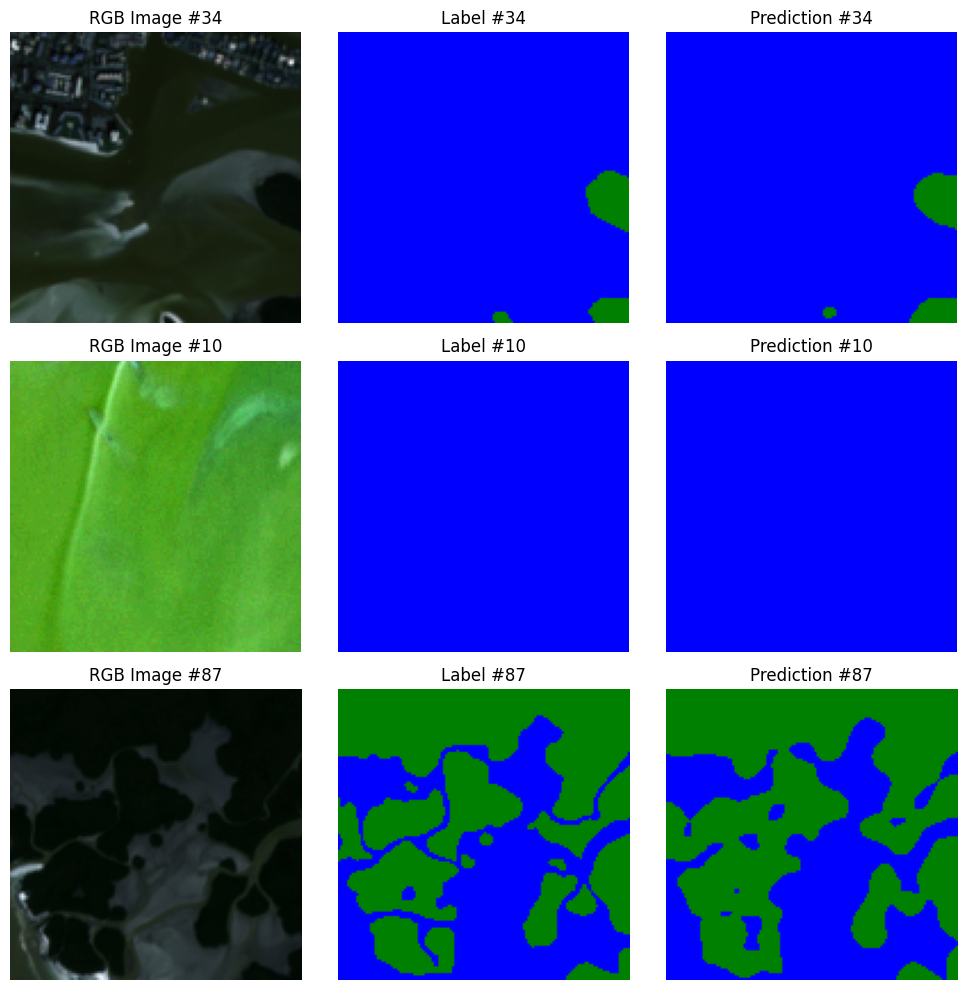

In [29]:
num_samples = 3
random_indices = np.random.choice(len(X_test), num_samples, replace=False)

plt.figure(figsize=(10, 10))

for i, idx in enumerate(random_indices):
    # RGB image
    plt.subplot(num_samples, 3, i*3 + 1)
    plt.imshow(normalize_rgb(X_test[idx]))
    plt.title(f"RGB Image #{idx}")
    plt.axis("off")

    # Ground truth (binary)
    plt.subplot(num_samples, 3, i*3 + 2)
    plt.imshow(colorize_mask(y_test[idx]))
    plt.title(f"Label #{idx}")
    plt.axis("off")

    # Prediction (binary)
    plt.subplot(num_samples, 3, i*3 + 3)
    plt.imshow(colorize_mask(y_pred_labels[idx]))
    plt.title(f"Prediction #{idx}")
    plt.axis("off")

plt.tight_layout()
plt.show()
